# FIFA World Cup 2026 — Exploratory Data Analysis
## Notebook 01: Data Inspection & Results Analysis

**Goal:** Initial inspection of all downloaded datasets, univariate,
bivariate and temporal analysis of historical international results.

**Datasets covered:**
- `martj42` — International results 1872–2026
- `patateriedata` — All matches with daily updates
- `lchikry` — Pre-calculated match features
- `joshfjelstul` — World Cup relational database
- `cashncarry` — FIFA Rankings historical
- `sarazahran1` — WC2026 Elo baseline
- `areezvisram12` — WC2026 fixture

In [1]:
# Standard library
from pathlib import Path

# Data
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px

# Project
import sys
sys.path.insert(0, str(Path("../..").resolve()))
from world_cup_2026.config import (
    RAW_DATA_DIR,
    EXTERNAL_DATA_DIR,
    FIGURES_DIR,
    RANDOM_SEED,
)

# Display settings
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.3f}".format)

# Plot style
sns.set_theme(style="darkgrid", palette="muted", font_scale=1.2)
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 120

# Reproducibility
np.random.seed(RANDOM_SEED)

print(f"RAW_DATA_DIR   : {RAW_DATA_DIR}")
print(f"EXTERNAL_DIR   : {EXTERNAL_DATA_DIR}")
print(f"FIGURES_DIR    : {FIGURES_DIR}")
print("Imports OK ✓")

2026-03-28 15:41:24.370 | INFO     | world_cup_2026.config:<module>:12 - PROJ_ROOT path is: C:\Users\feder\Documents\data_repos\world-cup-2026-predictor


RAW_DATA_DIR   : C:\Users\feder\Documents\data_repos\world-cup-2026-predictor\data\raw
EXTERNAL_DIR   : C:\Users\feder\Documents\data_repos\world-cup-2026-predictor\data\external
FIGURES_DIR    : C:\Users\feder\Documents\data_repos\world-cup-2026-predictor\outputs\figures
Imports OK ✓


## 1. Data Loading
### Initial load and inspection of all datasets

In [2]:
# ---------------------------------------------------------------------------
# Dataset 1 — martj42: International results 1872-2026
# ---------------------------------------------------------------------------
df_results = pd.read_csv(RAW_DATA_DIR / "martj42_results" / "results.csv", parse_dates=["date"])
df_shootouts = pd.read_csv(RAW_DATA_DIR / "martj42_results" / "shootouts.csv", parse_dates=["date"])
df_goalscorers = pd.read_csv(RAW_DATA_DIR / "martj42_results" / "goalscorers.csv", parse_dates=["date"])
df_former_names = pd.read_csv(RAW_DATA_DIR / "martj42_results" / "former_names.csv")

# ---------------------------------------------------------------------------
# Dataset 2 — patateriedata: All matches with daily updates
# ---------------------------------------------------------------------------
df_all_matches = pd.read_csv(RAW_DATA_DIR / "patateriedata_results" / "all_matches.csv", parse_dates=["date"])
df_countries = pd.read_csv(RAW_DATA_DIR / "patateriedata_results" / "countries_names.csv")

# ---------------------------------------------------------------------------
# Dataset 3 — lchikry: Pre-calculated features
# ---------------------------------------------------------------------------
df_teams_form = pd.read_csv(RAW_DATA_DIR / "lchikry_features" / "teams_form.csv")
df_match_features = pd.read_csv(RAW_DATA_DIR / "lchikry_features" / "teams_match_features.csv")

# ---------------------------------------------------------------------------
# Dataset 4 — joshfjelstul: World Cup relational database
# ---------------------------------------------------------------------------
df_wc_matches = pd.read_csv(RAW_DATA_DIR / "joshfjelstul_worldcup" / "matches.csv")
df_wc_groups = pd.read_csv(RAW_DATA_DIR / "joshfjelstul_worldcup" / "groups.csv")
df_wc_goals = pd.read_csv(RAW_DATA_DIR / "joshfjelstul_worldcup" / "goals.csv")
df_wc_penalties = pd.read_csv(RAW_DATA_DIR / "joshfjelstul_worldcup" / "penalty_kicks.csv")
df_wc_squads = pd.read_csv(RAW_DATA_DIR / "joshfjelstul_worldcup" / "squads.csv")

# ---------------------------------------------------------------------------
# Dataset 5 — cashncarry: FIFA Rankings
# ---------------------------------------------------------------------------
df_rankings = pd.read_csv(RAW_DATA_DIR / "cashncarry_rankings" / "fifa_ranking-2024-06-20.csv", parse_dates=["rank_date"])

# ---------------------------------------------------------------------------
# Dataset 6 — sarazahran1: WC2026 Elo baseline
# ---------------------------------------------------------------------------
df_elo_baseline = pd.read_csv(RAW_DATA_DIR / "sarazahran1_baseline" / "future_match_probabilities_baseline.csv")

# ---------------------------------------------------------------------------
# Dataset 7 — areezvisram12: WC2026 fixture
# ---------------------------------------------------------------------------
df_fixture = pd.read_csv(RAW_DATA_DIR / "areezvisram12_fixture" / "matches.csv")
df_teams_2026 = pd.read_csv(RAW_DATA_DIR / "areezvisram12_fixture" / "teams.csv")
df_stages = pd.read_csv(RAW_DATA_DIR / "areezvisram12_fixture" / "tournament_stages.csv")

print("All datasets loaded ✓")
print(f"\n{'Dataset':<25} {'Shape':>12}")
print("-" * 40)
for name, df in [
    ("df_results",        df_results),
    ("df_shootouts",      df_shootouts),
    ("df_goalscorers",    df_goalscorers),
    ("df_all_matches",    df_all_matches),
    ("df_teams_form",     df_teams_form),
    ("df_match_features", df_match_features),
    ("df_wc_matches",     df_wc_matches),
    ("df_rankings",       df_rankings),
    ("df_elo_baseline",   df_elo_baseline),
    ("df_fixture",        df_fixture),
    ("df_teams_2026",     df_teams_2026),
]:
    print(f"{name:<25} {str(df.shape):>12}")

All datasets loaded ✓

Dataset                          Shape
----------------------------------------
df_results                  (49071, 9)
df_shootouts                  (665, 5)
df_goalscorers              (47555, 8)
df_all_matches              (51384, 8)
df_teams_form              (102094, 5)
df_match_features          (43364, 35)
df_wc_matches                (900, 37)
df_rankings                 (67472, 8)
df_elo_baseline               (72, 13)
df_fixture                    (104, 8)
df_teams_2026                  (48, 5)


### 1.1 Initial inspection by dataset

In [3]:
print("=" * 60)
print("df_results — International Football Results 1872-2026")
print("=" * 60)
print(f"\nShape: {df_results.shape}")
print(f"Date range: {df_results['date'].min().date()} → {df_results['date'].max().date()}")
print(f"\nDtypes:\n{df_results.dtypes}")
print(f"\nNulls:\n{df_results.isnull().sum()}")
print(f"\nDuplicates: {df_results.duplicated().sum()}")
print(f"\nSample:\n{df_results.head(3).to_string()}")
print(f"\nTournament types ({df_results['tournament'].nunique()} unique):")
print(df_results['tournament'].value_counts().head(15).to_string())

df_results — International Football Results 1872-2026

Shape: (49071, 9)
Date range: 1872-11-30 → 2026-01-26

Dtypes:
date          datetime64[ns]
home_team             object
away_team             object
home_score             int64
away_score             int64
tournament            object
city                  object
country               object
neutral                 bool
dtype: object

Nulls:
date          0
home_team     0
away_team     0
home_score    0
away_score    0
tournament    0
city          0
country       0
neutral       0
dtype: int64

Duplicates: 0

Sample:
        date home_team away_team  home_score  away_score tournament     city   country  neutral
0 1872-11-30  Scotland   England           0           0   Friendly  Glasgow  Scotland    False
1 1873-03-08   England  Scotland           4           2   Friendly   London   England    False
2 1874-03-07  Scotland   England           2           1   Friendly  Glasgow  Scotland    False

Tournament types (191 unique):
to

In [4]:
print("=" * 60)
print("df_fixture — WC2026 Fixture (104 matches)")
print("=" * 60)
print(f"\nColumns: {df_fixture.columns.tolist()}")
print(f"\nNulls:\n{df_fixture.isnull().sum()}")
print(f"\nSample:\n{df_fixture.head(10).to_string()}")

print("\n" + "=" * 60)
print("df_teams_2026 — 48 Qualified Teams")
print("=" * 60)
print(f"\nColumns: {df_teams_2026.columns.tolist()}")
print(f"\n{df_teams_2026.to_string()}")

df_fixture — WC2026 Fixture (104 matches)

Columns: ['id', 'match_number', 'home_team_id', 'away_team_id', 'city_id', 'stage_id', 'kickoff_at', 'match_label']

Nulls:
id               0
match_number     0
home_team_id    32
away_team_id    32
city_id          0
stage_id         0
kickoff_at       0
match_label      0
dtype: int64

Sample:
   id  match_number  home_team_id  away_team_id  city_id  stage_id              kickoff_at match_label
0   1             1         1.000         2.000       15         1  2026-06-11 15:00:00-06     Group A
1   2             2         3.000         4.000       14         1  2026-06-11 22:00:00-06     Group A
2   3             3         5.000         6.000       12         1  2026-06-12 15:00:00-04     Group B
3   4             4        13.000        14.000        6         1  2026-06-12 21:00:00-07     Group D
4   5             5         7.000         8.000       10         1  2026-06-13 15:00:00-07     Group B
5   6             6         9.000        

In [5]:
print("=" * 60)
print("df_elo_baseline — WC2026 Elo Match Probability Baseline")
print("=" * 60)
print(f"\nColumns: {df_elo_baseline.columns.tolist()}")
print(f"\nSample:\n{df_elo_baseline.head(10).to_string()}")
print(f"\nStats:\n{df_elo_baseline.describe().to_string()}")

df_elo_baseline — WC2026 Elo Match Probability Baseline

Columns: ['group', 'home_team', 'away_team', 'date', 'tournament', 'home_elo', 'away_elo', 'elo_diff', 'home_injury_flag', 'away_injury_flag', 'p_home_win', 'p_draw', 'p_away_win']

Sample:
  group     home_team       away_team  date                   tournament  home_elo  away_elo  elo_diff  home_injury_flag  away_injury_flag  p_home_win  p_draw  p_away_win
0     A        Mexico    South Africa   NaN  FIFA World Cup 2026 - Group      1890  1600.000   290.000                 0                 0       0.709   0.158       0.134
1     A        Mexico     South Korea   NaN  FIFA World Cup 2026 - Group      1890  1755.000   135.000                 0                 0       0.547   0.201       0.251
2     A        Mexico  UEFA_Playoff_D   NaN  FIFA World Cup 2026 - Group      1890       NaN       NaN                 0                 0       0.360   0.280       0.360
3     A  South Africa     South Korea   NaN  FIFA World Cup 2026 - Gr

In [6]:
print("=" * 60)
print("df_match_features — Pre-calculated Match Features (35 cols)")
print("=" * 60)
print(f"\nColumns:\n{df_match_features.columns.tolist()}")
print(f"\nNulls (top 10):\n{df_match_features.isnull().sum().sort_values(ascending=False).head(10)}")
print(f"\nDate range: {df_match_features.iloc[:,0].min()} → {df_match_features.iloc[:,0].max()}")
print(f"\nSample:\n{df_match_features.head(3).to_string()}")

df_match_features — Pre-calculated Match Features (35 cols)

Columns:
['home_elo', 'away_elo', 'elo_diff', 'home_avg_overall', 'home_max_overall', 'home_avg_attack', 'home_avg_defense', 'home_avg_pace', 'home_avg_shooting', 'home_avg_passing', 'away_avg_overall', 'away_max_overall', 'away_avg_attack', 'away_avg_defense', 'away_avg_pace', 'away_avg_shooting', 'away_avg_passing', 'overall_diff', 'attack_diff', 'defense_diff', 'home_form_scored', 'home_form_conceded', 'home_form_win_rate', 'away_form_scored', 'away_form_conceded', 'away_form_win_rate', 'is_neutral', 'is_world_cup', 'is_continental', 'home_goals', 'away_goals', '_home_team', '_away_team', '_date', '_tournament']

Nulls (top 10):
away_avg_pace        801
away_avg_passing     801
away_avg_shooting    801
home_avg_pace        697
home_avg_passing     697
home_avg_shooting    697
home_elo               0
elo_diff               0
away_elo               0
home_avg_defense       0
dtype: int64

Date range: 952.1888553525022 → 210

### 1.2 Fixture resolution — join teams to get real names

In [7]:
# Merge paso 1 — home team
df_fixture_named = df_fixture.merge(
    df_teams_2026[["id", "team_name", "fifa_code", "group_letter"]].rename(columns={
        "id": "home_team_id",
        "team_name": "home_team",
        "fifa_code": "home_code",
        "group_letter": "group",
    }),
    on="home_team_id",
    how="left",
)

# Merge paso 2 — away team
df_fixture_named = df_fixture_named.merge(
    df_teams_2026[["id", "team_name", "fifa_code"]].rename(columns={
        "id": "away_team_id",
        "team_name": "away_team",
        "fifa_code": "away_code",
    }),
    on="away_team_id",
    how="left",
)

# Parse kickoff datetime
df_fixture_named["kickoff_at"] = pd.to_datetime(df_fixture_named["kickoff_at"], utc=True)

# Solo fase de grupos (stage_id == 1)
df_group_stage = df_fixture_named[df_fixture_named["stage_id"] == 1].copy()

print(f"Fixture total: {len(df_fixture_named)} matches")
print(f"Group stage:   {len(df_group_stage)} matches")
print(f"\nGroup stage sample:")
print(
    df_group_stage[["match_number", "group", "home_team", "away_team", "kickoff_at"]]
    .head(12)
    .to_string(index=False)
)

print(f"\nStages distribution:")
print(df_fixture_named["stage_id"].value_counts().sort_index().to_string())

Fixture total: 104 matches
Group stage:   72 matches

Group stage sample:
 match_number group             home_team             away_team                kickoff_at
            1     A                Mexico          South Africa 2026-06-11 21:00:00+00:00
            2     A           South Korea Winner UEFA Playoff D 2026-06-12 04:00:00+00:00
            3     B                Canada Winner UEFA Playoff A 2026-06-12 19:00:00+00:00
            4     D                   USA              Paraguay 2026-06-13 04:00:00+00:00
            5     B                 Qatar           Switzerland 2026-06-13 22:00:00+00:00
            6     C                Brazil               Morocco 2026-06-13 22:00:00+00:00
            7     C                 Haiti              Scotland 2026-06-14 01:00:00+00:00
            8     D             Australia Winner UEFA Playoff C 2026-06-14 07:00:00+00:00
            9     E               Germany               Curaçao 2026-06-14 18:00:00+00:00
           10     F       

In [8]:
confirmed = df_teams_2026[df_teams_2026["is_placeholder"] == False]
placeholders = df_teams_2026[df_teams_2026["is_placeholder"] == True]

print(f"Confirmed teams : {len(confirmed)}")
print(f"Placeholders    : {len(placeholders)}")
print(f"\nPlaceholders:")
print(placeholders[["team_name", "fifa_code", "group_letter"]].to_string(index=False))

print(f"\nConfirmed teams by group:")
for group in sorted(confirmed["group_letter"].unique()):
    teams = confirmed[confirmed["group_letter"] == group]["team_name"].tolist()
    print(f"  Group {group}: {', '.join(teams)}")

Confirmed teams : 42
Placeholders    : 6

Placeholders:
            team_name fifa_code group_letter
Winner UEFA Playoff D      UEPD            A
Winner UEFA Playoff A      UEPA            B
Winner UEFA Playoff C      UEPC            D
Winner UEFA Playoff B      UEPB            F
Winner FIFA Playoff 2      FP02            I
Winner FIFA Playoff 1      FP01            K

Confirmed teams by group:
  Group A: Mexico, South Africa, South Korea
  Group B: Canada, Qatar, Switzerland
  Group C: Brazil, Morocco, Haiti, Scotland
  Group D: USA, Paraguay, Australia
  Group E: Germany, Curaçao, Côte d'Ivoire, Ecuador
  Group F: Netherlands, Japan, Tunisia
  Group G: Belgium, Egypt, IR Iran, New Zealand
  Group H: Spain, Cabo Verde, Saudi Arabia, Uruguay
  Group I: France, Senegal, Norway
  Group J: Argentina, Algeria, Austria, Jordan
  Group K: Portugal, Uzbekistan, Colombia
  Group L: England, Croatia, Ghana, Panama


## 2. Univariate Analysis
### 2.1 Goals distribution — Historical international matches

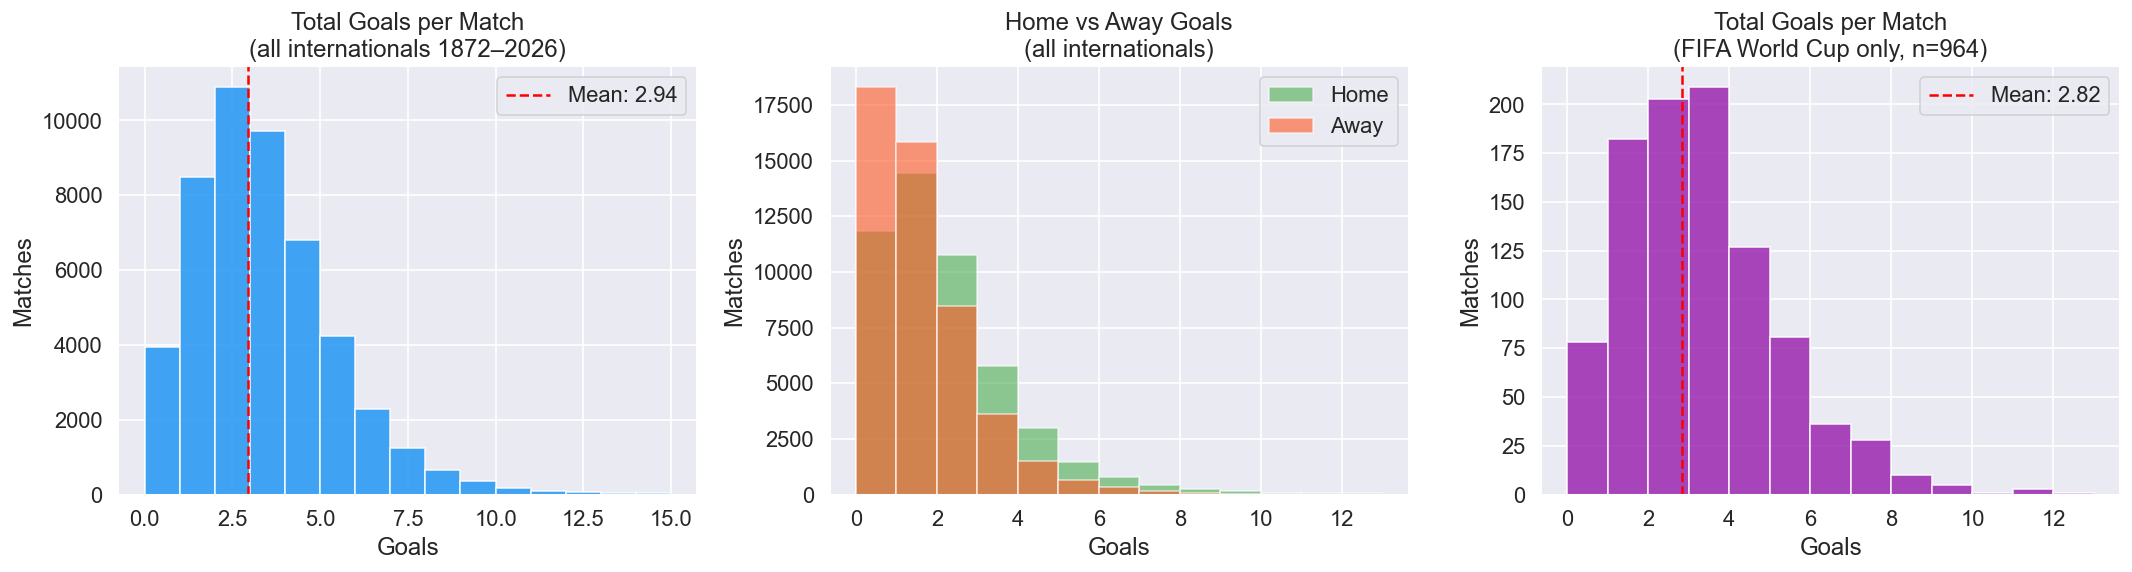


All internationals — mean goals/match : 2.938
World Cup only  — mean goals/match    : 2.822

Result distribution (all):
result
Home Win   49.000
Away Win   28.270
Draw       22.730

Result distribution (World Cup):
result
Home Win   45.540
Away Win   32.260
Draw       22.200


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Total goals per match ---
df_results["total_goals"] = df_results["home_score"] + df_results["away_score"]

axes[0].hist(
    df_results["total_goals"],
    bins=range(0, 16),
    edgecolor="white",
    color="#2196F3",
    alpha=0.85,
)
axes[0].set_title("Total Goals per Match\n(all internationals 1872–2026)")
axes[0].set_xlabel("Goals")
axes[0].set_ylabel("Matches")
axes[0].axvline(df_results["total_goals"].mean(), color="red", linestyle="--", label=f"Mean: {df_results['total_goals'].mean():.2f}")
axes[0].legend()

# --- Home vs Away goals ---
axes[1].hist(df_results["home_score"], bins=range(0, 14), alpha=0.6, label="Home", color="#4CAF50", edgecolor="white")
axes[1].hist(df_results["away_score"], bins=range(0, 14), alpha=0.6, label="Away", color="#FF5722", edgecolor="white")
axes[1].set_title("Home vs Away Goals\n(all internationals)")
axes[1].set_xlabel("Goals")
axes[1].set_ylabel("Matches")
axes[1].legend()

# --- World Cup only ---
df_wc_only = df_results[df_results["tournament"] == "FIFA World Cup"]
axes[2].hist(
    df_wc_only["total_goals"],
    bins=range(0, 14),
    edgecolor="white",
    color="#9C27B0",
    alpha=0.85,
)
axes[2].set_title(f"Total Goals per Match\n(FIFA World Cup only, n={len(df_wc_only):,})")
axes[2].set_xlabel("Goals")
axes[2].set_ylabel("Matches")
axes[2].axvline(df_wc_only["total_goals"].mean(), color="red", linestyle="--", label=f"Mean: {df_wc_only['total_goals'].mean():.2f}")
axes[2].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "01_goals_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nAll internationals — mean goals/match : {df_results['total_goals'].mean():.3f}")
print(f"World Cup only  — mean goals/match    : {df_wc_only['total_goals'].mean():.3f}")
print(f"\nResult distribution (all):")
df_results["result"] = df_results.apply(
    lambda r: "Home Win" if r.home_score > r.away_score
    else ("Away Win" if r.home_score < r.away_score else "Draw"),
    axis=1
)
print(df_results["result"].value_counts(normalize=True).mul(100).round(2).to_string())
print(f"\nResult distribution (World Cup):")
df_wc_only = df_results[df_results["tournament"] == "FIFA World Cup"].copy()
df_wc_only["result"] = df_wc_only.apply(
    lambda r: "Home Win" if r.home_score > r.away_score
    else ("Away Win" if r.home_score < r.away_score else "Draw"),
    axis=1
)
print(df_wc_only["result"].value_counts(normalize=True).mul(100).round(2).to_string())

### 2.2 Match results distribution — Home advantage analysis

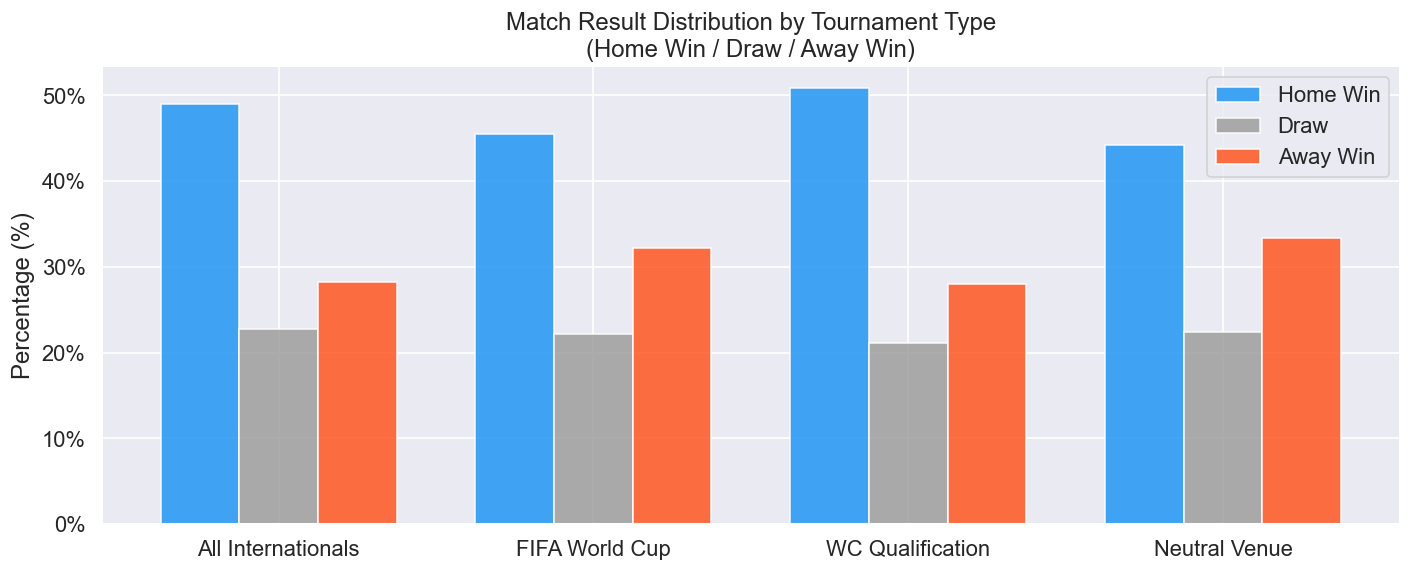

In [10]:
# Filtros relevantes
tournament_filters = {
    "All Internationals": df_results,
    "FIFA World Cup": df_results[df_results["tournament"] == "FIFA World Cup"],
    "WC Qualification": df_results[df_results["tournament"] == "FIFA World Cup qualification"],
    "Neutral Venue": df_results[df_results["neutral"] == True],
}

fig, ax = plt.subplots(figsize=(12, 5))

categories = ["Home Win", "Draw", "Away Win"]
colors = ["#2196F3", "#9E9E9E", "#FF5722"]
x = np.arange(len(tournament_filters))
width = 0.25

for i, cat in enumerate(categories):
    vals = []
    for label, df_f in tournament_filters.items():
        df_tmp = df_f.copy()
        df_tmp["result"] = df_tmp.apply(
            lambda r: "Home Win" if r.home_score > r.away_score
            else ("Away Win" if r.home_score < r.away_score else "Draw"),
            axis=1
        )
        vals.append(df_tmp["result"].value_counts(normalize=True).get(cat, 0) * 100)
    ax.bar(x + i * width, vals, width, label=cat, color=colors[i], alpha=0.85, edgecolor="white")

ax.set_xticks(x + width)
ax.set_xticklabels(list(tournament_filters.keys()))
ax.set_ylabel("Percentage (%)")
ax.set_title("Match Result Distribution by Tournament Type\n(Home Win / Draw / Away Win)")
ax.legend()
ax.yaxis.set_major_formatter(mticker.PercentFormatter())

plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_result_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

### 2.3 Historical goals trend — How has football evolved since 1872?

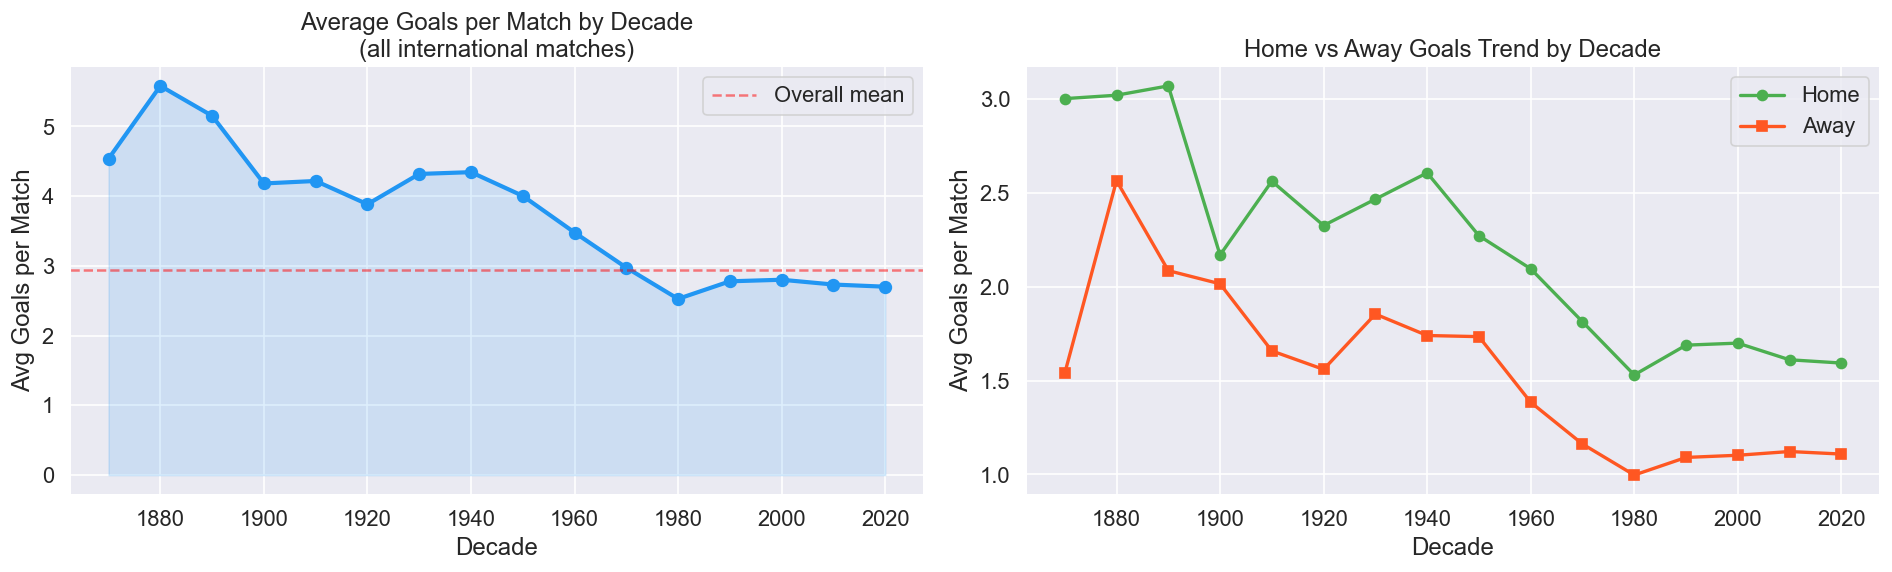

Goals trend by decade:
 decade  matches  avg_goals  avg_home  avg_away
   1950     1651      4.004     2.271     1.733
   1960     2971      3.479     2.095     1.384
   1970     4133      2.975     1.813     1.162
   1980     5025      2.527     1.530     0.997
   1990     6944      2.779     1.688     1.091
   2000     9525      2.801     1.699     1.102
   2010     9756      2.733     1.610     1.122
   2020     5732      2.702     1.593     1.109


In [11]:
# Goals per match by decade
df_results["year"] = df_results["date"].dt.year
df_results["decade"] = (df_results["year"] // 10) * 10

decade_stats = (
    df_results.groupby("decade")
    .agg(
        matches=("total_goals", "count"),
        avg_goals=("total_goals", "mean"),
        avg_home=("home_score", "mean"),
        avg_away=("away_score", "mean"),
    )
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Avg goals per decade ---
axes[0].plot(
    decade_stats["decade"],
    decade_stats["avg_goals"],
    marker="o", linewidth=2.5, color="#2196F3", markersize=7
)
axes[0].fill_between(decade_stats["decade"], decade_stats["avg_goals"], alpha=0.15, color="#2196F3")
axes[0].set_title("Average Goals per Match by Decade\n(all international matches)")
axes[0].set_xlabel("Decade")
axes[0].set_ylabel("Avg Goals per Match")
axes[0].axhline(df_results["total_goals"].mean(), color="red", linestyle="--", alpha=0.5, label="Overall mean")
axes[0].legend()

# --- Home vs Away trend ---
axes[1].plot(decade_stats["decade"], decade_stats["avg_home"], marker="o", label="Home", color="#4CAF50", linewidth=2)
axes[1].plot(decade_stats["decade"], decade_stats["avg_away"], marker="s", label="Away", color="#FF5722", linewidth=2)
axes[1].set_title("Home vs Away Goals Trend by Decade")
axes[1].set_xlabel("Decade")
axes[1].set_ylabel("Avg Goals per Match")
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_goals_trend_by_decade.png", dpi=150, bbox_inches="tight")
plt.show()

print("Goals trend by decade:")
print(decade_stats.tail(8).to_string(index=False))

### 2.4 FIFA Rankings distribution — Current WC2026 qualified teams

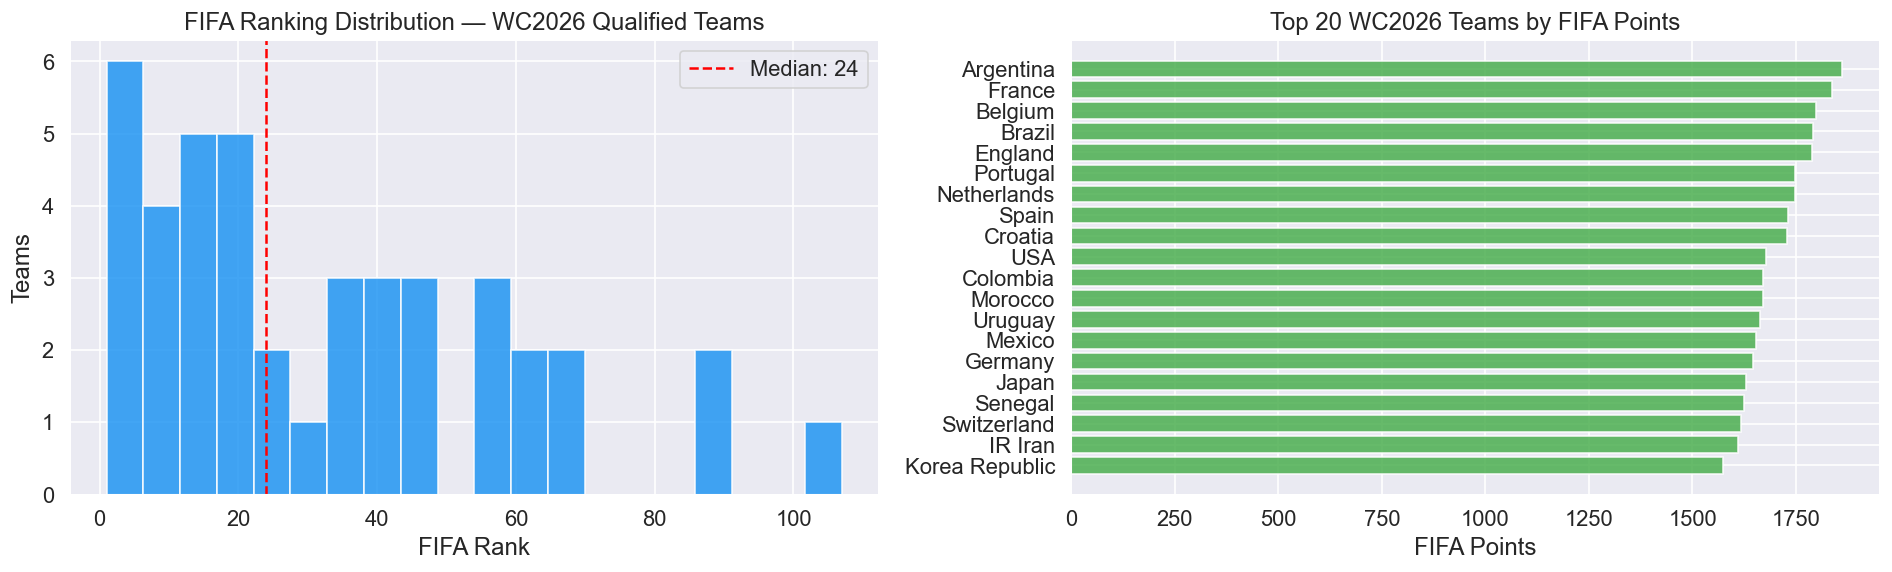

Top 10 WC2026 teams by FIFA ranking:
country_full   rank  total_points
   Argentina  1.000      1860.140
      France  2.000      1837.470
     Belgium  3.000      1797.980
      Brazil  4.000      1791.850
     England  5.000      1787.880
    Portugal  6.000      1747.040
 Netherlands  7.000      1746.660
       Spain  8.000      1729.920
     Croatia  9.000      1728.300
         USA 11.000      1676.520


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Rank distribution ---
axes[0].hist(df_rank_wc["rank"], bins=20, color="#2196F3", edgecolor="white", alpha=0.85)
axes[0].set_title("FIFA Ranking Distribution — WC2026 Qualified Teams")
axes[0].set_xlabel("FIFA Rank")
axes[0].set_ylabel("Teams")
axes[0].axvline(
    df_rank_wc["rank"].median(), color="red", linestyle="--",
    label=f"Median: {df_rank_wc['rank'].median():.0f}"
)
axes[0].legend()

# --- Top 20 by points ---
df_top20 = df_rank_wc.nsmallest(20, "rank").sort_values("rank")
axes[1].barh(df_top20["country_full"], df_top20["total_points"], color="#4CAF50", alpha=0.85, edgecolor="white")
axes[1].invert_yaxis()
axes[1].set_title("Top 20 WC2026 Teams by FIFA Points")
axes[1].set_xlabel("FIFA Points")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "04_rankings_wc2026.png", dpi=150, bbox_inches="tight")
plt.show()

print("Top 10 WC2026 teams by FIFA ranking:")
print(df_top20[["country_full", "rank", "total_points"]].head(10).to_string(index=False))

## 2. Bivariate Analysis
### 2.1 Elo difference vs match result — does Elo predict outcomes?

C:\Users\feder\AppData\Local\Temp\ipykernel_14692\3375776638.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(data_to_plot, labels=result_order, patch_artist=True,


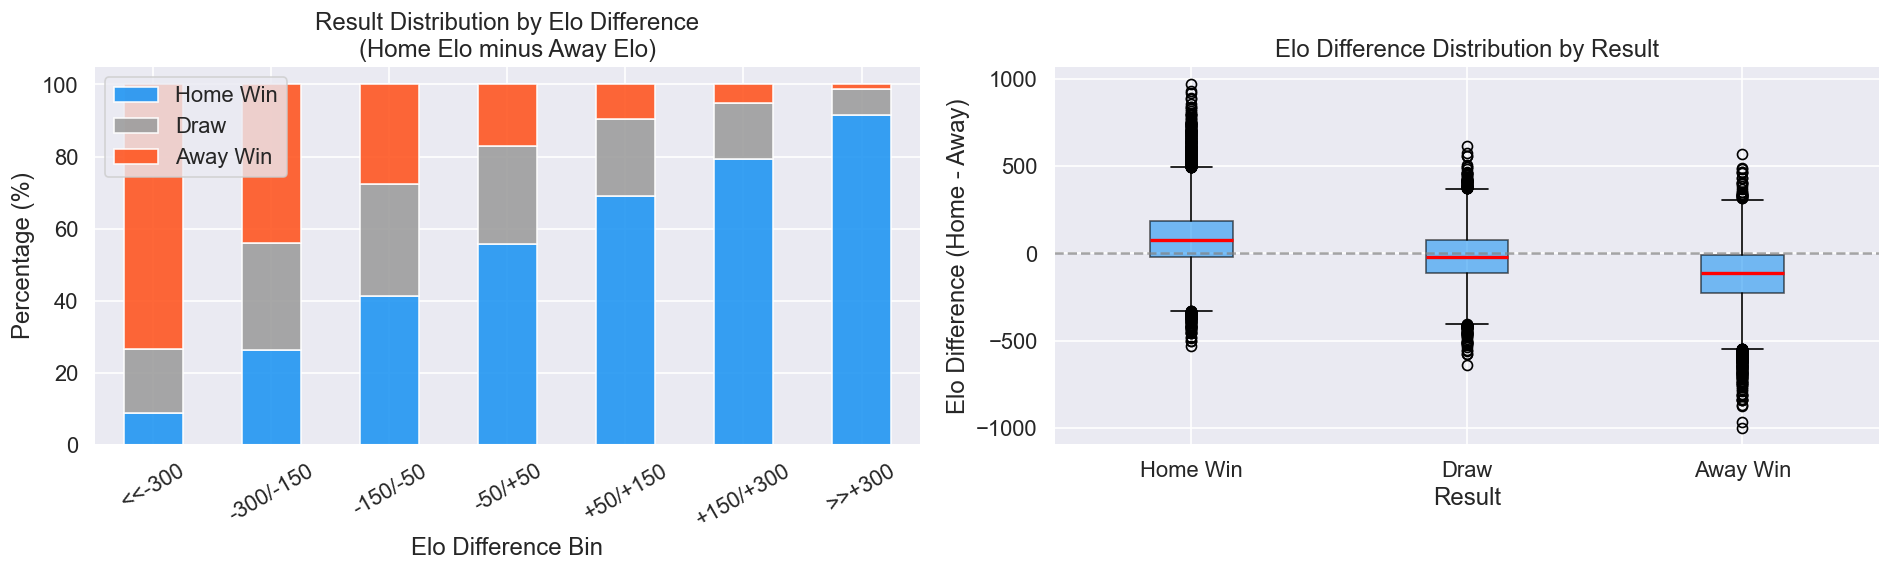

Win rate by Elo difference bin:
result        Away Win   Draw  Home Win
elo_diff_bin                           
<<-300          73.400 17.900     8.700
-300/-150       43.900 29.700    26.400
-150/-50        27.700 30.900    41.400
-50/+50         17.100 27.200    55.700
+50/+150         9.700 21.300    69.000
+150/+300        5.300 15.400    79.400
>>+300           1.200  7.200    91.600


In [17]:
# Use df_match_features which has pre-calculated Elo and result
df_mf = df_match_features.copy()

# Build result column from goals
df_mf["result"] = df_mf.apply(
    lambda r: "Home Win" if r.home_goals > r.away_goals
    else ("Away Win" if r.home_goals < r.away_goals else "Draw"),
    axis=1
)

# Bin elo_diff into buckets
bins = [-1500, -300, -150, -50, 50, 150, 300, 1500]
labels = ["<<-300", "-300/-150", "-150/-50", "-50/+50", "+50/+150", "+150/+300", ">>+300"]
df_mf["elo_diff_bin"] = pd.cut(df_mf["elo_diff"], bins=bins, labels=labels)

# Win rate by elo_diff bin
elo_result = (
    df_mf.groupby(["elo_diff_bin", "result"], observed=True)
    .size()
    .unstack(fill_value=0)
)
elo_result_pct = elo_result.div(elo_result.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Stacked bar: result % by Elo diff bin ---
elo_result_pct[["Home Win", "Draw", "Away Win"]].plot(
    kind="bar", stacked=True, ax=axes[0],
    color=["#2196F3", "#9E9E9E", "#FF5722"],
    edgecolor="white", alpha=0.9
)
axes[0].set_title("Result Distribution by Elo Difference\n(Home Elo minus Away Elo)")
axes[0].set_xlabel("Elo Difference Bin")
axes[0].set_ylabel("Percentage (%)")
axes[0].tick_params(axis="x", rotation=30)
axes[0].legend(loc="upper left")

# --- Boxplot: elo_diff by result ---
result_order = ["Home Win", "Draw", "Away Win"]
data_to_plot = [df_mf[df_mf["result"] == r]["elo_diff"].dropna() for r in result_order]
axes[1].boxplot(data_to_plot, labels=result_order, patch_artist=True,
    boxprops=dict(facecolor="#2196F3", alpha=0.6),
    medianprops=dict(color="red", linewidth=2))
axes[1].set_title("Elo Difference Distribution by Result")
axes[1].set_xlabel("Result")
axes[1].set_ylabel("Elo Difference (Home - Away)")
axes[1].axhline(0, color="gray", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "05_elo_vs_result.png", dpi=150, bbox_inches="tight")
plt.show()

print("Win rate by Elo difference bin:")
print(elo_result_pct.round(1).to_string())

### 2.2 FIFA Ranking difference vs result

Matches with ranking data (2015+): 8,556


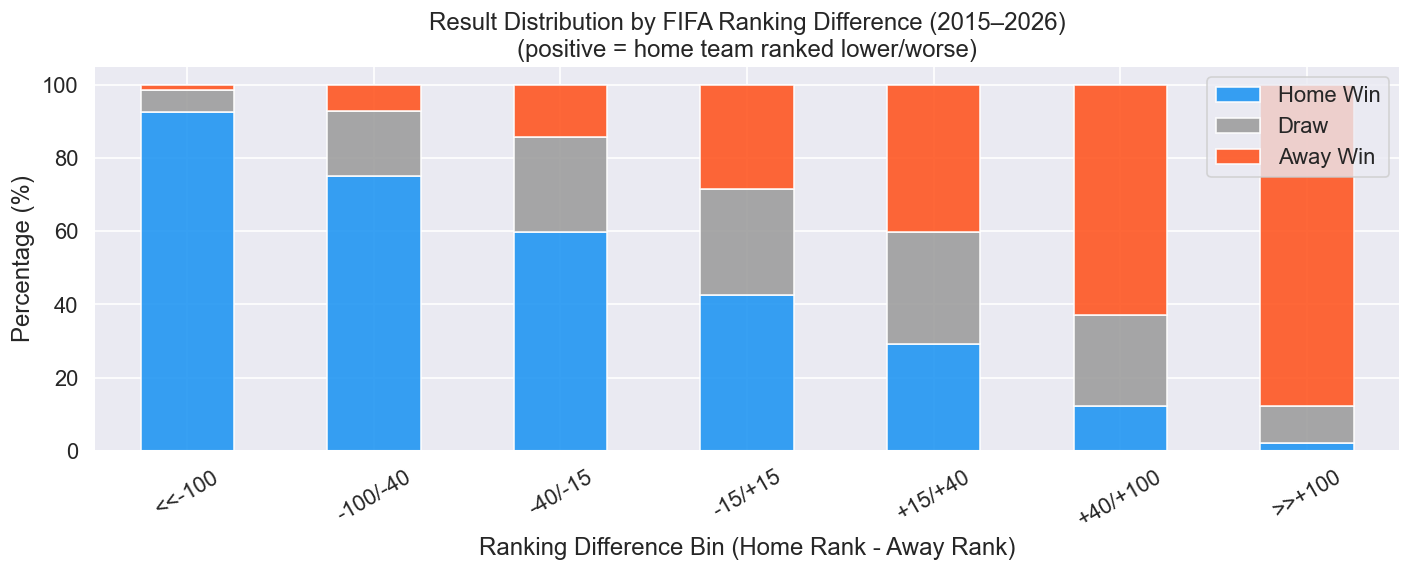


Win rate by FIFA ranking difference bin:
result         Away Win   Draw  Home Win
rank_diff_bin                           
<<-100            1.300  6.100    92.600
-100/-40          7.100 17.800    75.100
-40/-15          14.200 26.100    59.700
-15/+15          28.400 29.100    42.500
+15/+40          40.100 30.600    29.300
+40/+100         63.000 24.700    12.300
>>+100           87.900  9.900     2.300


In [18]:
# Merge rankings into df_match_features via team names
# Use df_results as base since it has team names
df_res = df_results.copy()
df_res["result"] = df_res.apply(
    lambda r: "Home Win" if r.home_score > r.away_score
    else ("Away Win" if r.home_score < r.away_score else "Draw"),
    axis=1
)

# Get latest ranking per team
rank_lookup = (
    df_rankings.sort_values("rank_date")
    .groupby("country_full")
    .last()
    .reset_index()[["country_full", "rank"]]
    .rename(columns={"country_full": "team", "rank": "fifa_rank"})
)

# Merge home and away rankings
df_res = df_res.merge(rank_lookup.rename(columns={"team": "home_team", "fifa_rank": "home_rank"}), on="home_team", how="left")
df_res = df_res.merge(rank_lookup.rename(columns={"team": "away_team", "fifa_rank": "away_rank"}), on="away_team", how="left")
df_res["rank_diff"] = df_res["home_rank"] - df_res["away_rank"]  # positive = home is lower ranked

# Only recent matches (2015+) where rankings are meaningful
df_ranked = df_res[df_res["date"].dt.year >= 2015].dropna(subset=["home_rank", "away_rank"])

print(f"Matches with ranking data (2015+): {len(df_ranked):,}")

bins_r = [-500, -100, -40, -15, 15, 40, 100, 500]
labels_r = ["<<-100", "-100/-40", "-40/-15", "-15/+15", "+15/+40", "+40/+100", ">>+100"]
df_ranked["rank_diff_bin"] = pd.cut(df_ranked["rank_diff"], bins=bins_r, labels=labels_r)

rank_result = (
    df_ranked.groupby(["rank_diff_bin", "result"], observed=True)
    .size()
    .unstack(fill_value=0)
)
rank_result_pct = rank_result.div(rank_result.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 5))
rank_result_pct[["Home Win", "Draw", "Away Win"]].plot(
    kind="bar", stacked=True, ax=ax,
    color=["#2196F3", "#9E9E9E", "#FF5722"],
    edgecolor="white", alpha=0.9
)
ax.set_title("Result Distribution by FIFA Ranking Difference (2015–2026)\n(positive = home team ranked lower/worse)")
ax.set_xlabel("Ranking Difference Bin (Home Rank - Away Rank)")
ax.set_ylabel("Percentage (%)")
ax.tick_params(axis="x", rotation=30)
ax.legend(loc="upper right")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "06_ranking_diff_vs_result.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nWin rate by FIFA ranking difference bin:")
print(rank_result_pct.round(1).to_string())

### 2.3 Correlation heatmap — all numeric features

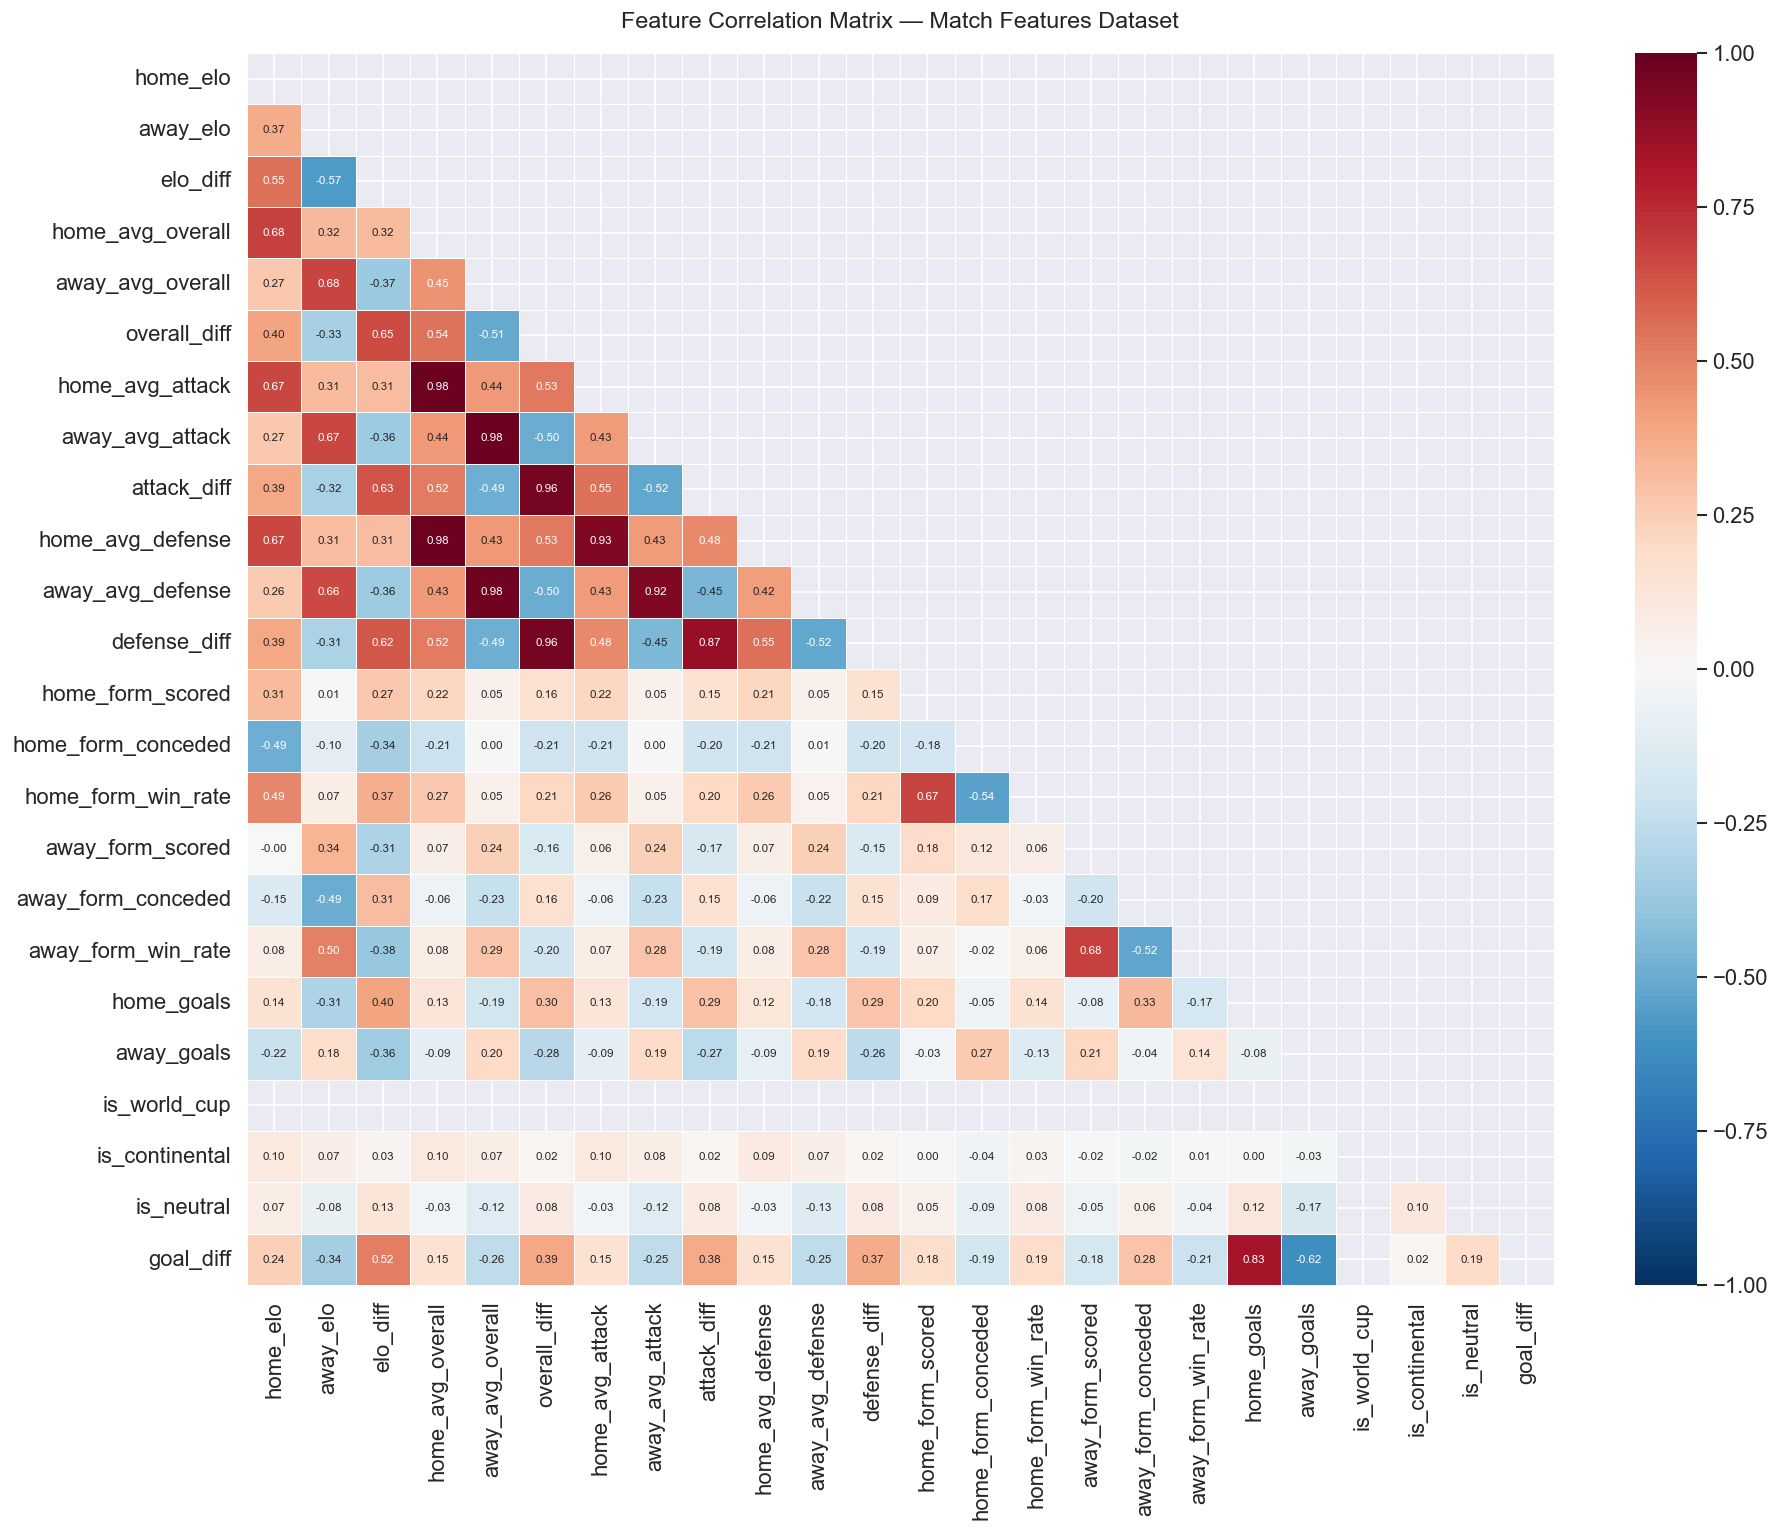

Top correlations with goal_diff (home_goals - away_goals):
home_goals           0.831
away_goals           0.619
elo_diff             0.515
overall_diff         0.389
attack_diff          0.379
defense_diff         0.372
away_elo             0.341
away_form_conceded   0.283
away_avg_overall     0.258
away_avg_attack      0.255


In [19]:
# Select numeric features from df_match_features
numeric_cols = [
    "home_elo", "away_elo", "elo_diff",
    "home_avg_overall", "away_avg_overall", "overall_diff",
    "home_avg_attack", "away_avg_attack", "attack_diff",
    "home_avg_defense", "away_avg_defense", "defense_diff",
    "home_form_scored", "home_form_conceded", "home_form_win_rate",
    "away_form_scored", "away_form_conceded", "away_form_win_rate",
    "home_goals", "away_goals",
    "is_world_cup", "is_continental", "is_neutral",
]

df_corr = df_mf[numeric_cols].copy()

# Add goal difference as proxy target
df_corr["goal_diff"] = df_corr["home_goals"] - df_corr["away_goals"]

corr_matrix = df_corr.corr()

fig, ax = plt.subplots(figsize=(16, 13))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1, vmax=1,
    ax=ax,
    annot_kws={"size": 7},
    linewidths=0.3,
)
ax.set_title("Feature Correlation Matrix — Match Features Dataset", fontsize=14, pad=15)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "07_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

# Top correlations with goal_diff (our main proxy target)
print("Top correlations with goal_diff (home_goals - away_goals):")
top_corr = (
    corr_matrix["goal_diff"]
    .drop("goal_diff")
    .abs()
    .sort_values(ascending=False)
    .head(10)
)
print(top_corr.round(3).to_string())

### 2.4 Form features — recent performance as predictor

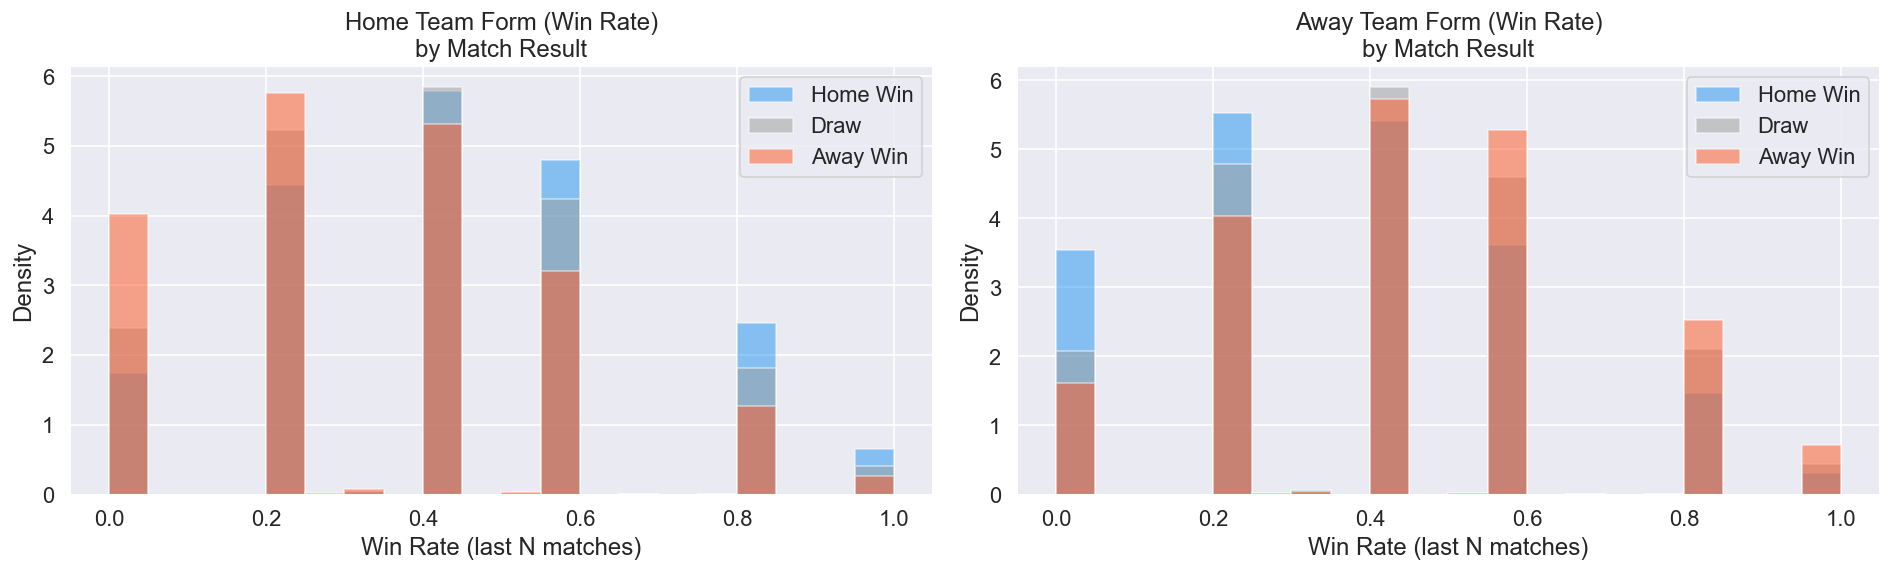

Mean form win rate by result:
          home_form_win_rate  away_form_win_rate
result                                          
Away Win               0.327               0.452
Draw                   0.391               0.412
Home Win               0.438               0.349


In [20]:
# Analyze home_form_win_rate and away_form_win_rate vs result
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, (form_col, label) in zip(axes, [
    ("home_form_win_rate", "Home Team Form (Win Rate)"),
    ("away_form_win_rate", "Away Team Form (Win Rate)"),
]):
    for result, color in zip(["Home Win", "Draw", "Away Win"], ["#2196F3", "#9E9E9E", "#FF5722"]):
        subset = df_mf[df_mf["result"] == result][form_col].dropna()
        ax.hist(subset, bins=20, alpha=0.5, label=result, color=color, edgecolor="white", density=True)
    ax.set_title(f"{label}\nby Match Result")
    ax.set_xlabel("Win Rate (last N matches)")
    ax.set_ylabel("Density")
    ax.legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "08_form_vs_result.png", dpi=150, bbox_inches="tight")
plt.show()

# Mean form by result
print("Mean form win rate by result:")
print(
    df_mf.groupby("result")[["home_form_win_rate", "away_form_win_rate"]]
    .mean()
    .round(3)
    .to_string()
)

## 3. Temporal Analysis
### 3.1 How has international football evolved since 1872?

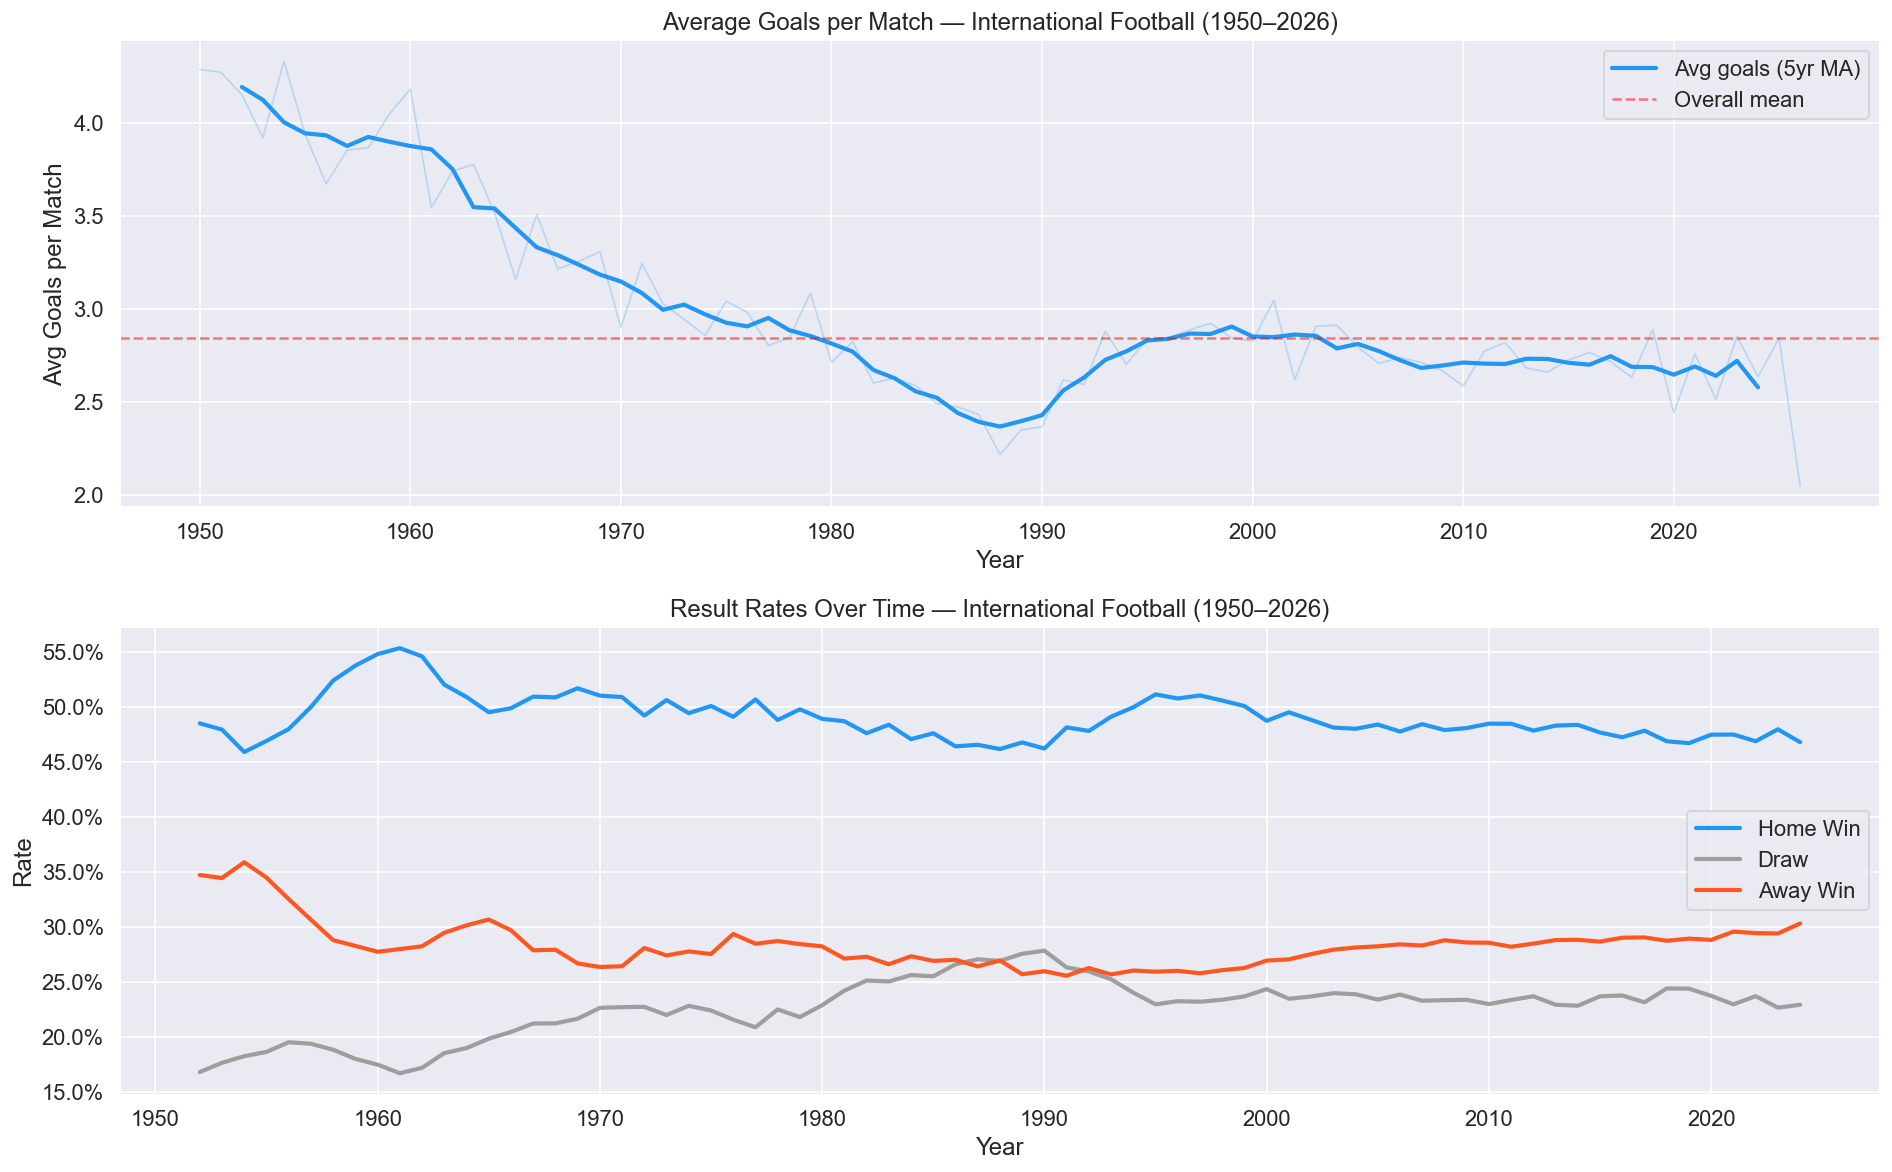

Result rates — last 5 years (2021-2026):
 year  matches  avg_goals  home_win_rate  draw_rate  away_win_rate
 2021     1115      2.759          0.487      0.225          0.288
 2022      969      2.515          0.497      0.227          0.276
 2023     1054      2.853          0.467      0.213          0.320
 2024     1229      2.637          0.462      0.249          0.289
 2025      997      2.844          0.483      0.219          0.298
 2026       21      2.048          0.429      0.238          0.333


In [21]:
# Goals and results trend by year (post-1950 for meaningful sample sizes)
df_modern = df_results[df_results["year"] >= 1950].copy()

yearly = (
    df_modern.groupby("year")
    .agg(
        matches=("total_goals", "count"),
        avg_goals=("total_goals", "mean"),
        home_win_rate=("result", lambda x: (x == "Home Win").mean()),
        draw_rate=("result", lambda x: (x == "Draw").mean()),
        away_win_rate=("result", lambda x: (x == "Away Win").mean()),
    )
    .reset_index()
)

# Smooth with 5-year rolling average
for col in ["avg_goals", "home_win_rate", "draw_rate", "away_win_rate"]:
    yearly[f"{col}_smooth"] = yearly[col].rolling(5, center=True).mean()

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# --- Goals per year ---
axes[0].plot(yearly["year"], yearly["avg_goals"], alpha=0.25, color="#2196F3", linewidth=1)
axes[0].plot(yearly["year"], yearly["avg_goals_smooth"], color="#2196F3", linewidth=2.5, label="Avg goals (5yr MA)")
axes[0].set_title("Average Goals per Match — International Football (1950–2026)")
axes[0].set_ylabel("Avg Goals per Match")
axes[0].set_xlabel("Year")
axes[0].axhline(df_modern["total_goals"].mean(), color="red", linestyle="--", alpha=0.5, label="Overall mean")
axes[0].legend()

# --- Result rates ---
for col, label, color in [
    ("home_win_rate_smooth", "Home Win", "#2196F3"),
    ("draw_rate_smooth", "Draw", "#9E9E9E"),
    ("away_win_rate_smooth", "Away Win", "#FF5722"),
]:
    axes[1].plot(yearly["year"], yearly[col], label=label, color=color, linewidth=2.5)

axes[1].set_title("Result Rates Over Time — International Football (1950–2026)")
axes[1].set_ylabel("Rate")
axes[1].set_xlabel("Year")
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "09_temporal_evolution.png", dpi=150, bbox_inches="tight")
plt.show()

print("Result rates — last 5 years (2021-2026):")
print(
    yearly[yearly["year"] >= 2021][
        ["year", "matches", "avg_goals", "home_win_rate", "draw_rate", "away_win_rate"]
    ].round(3).to_string(index=False)
)

### 3.2 World Cup performance — which teams have historically dominated?

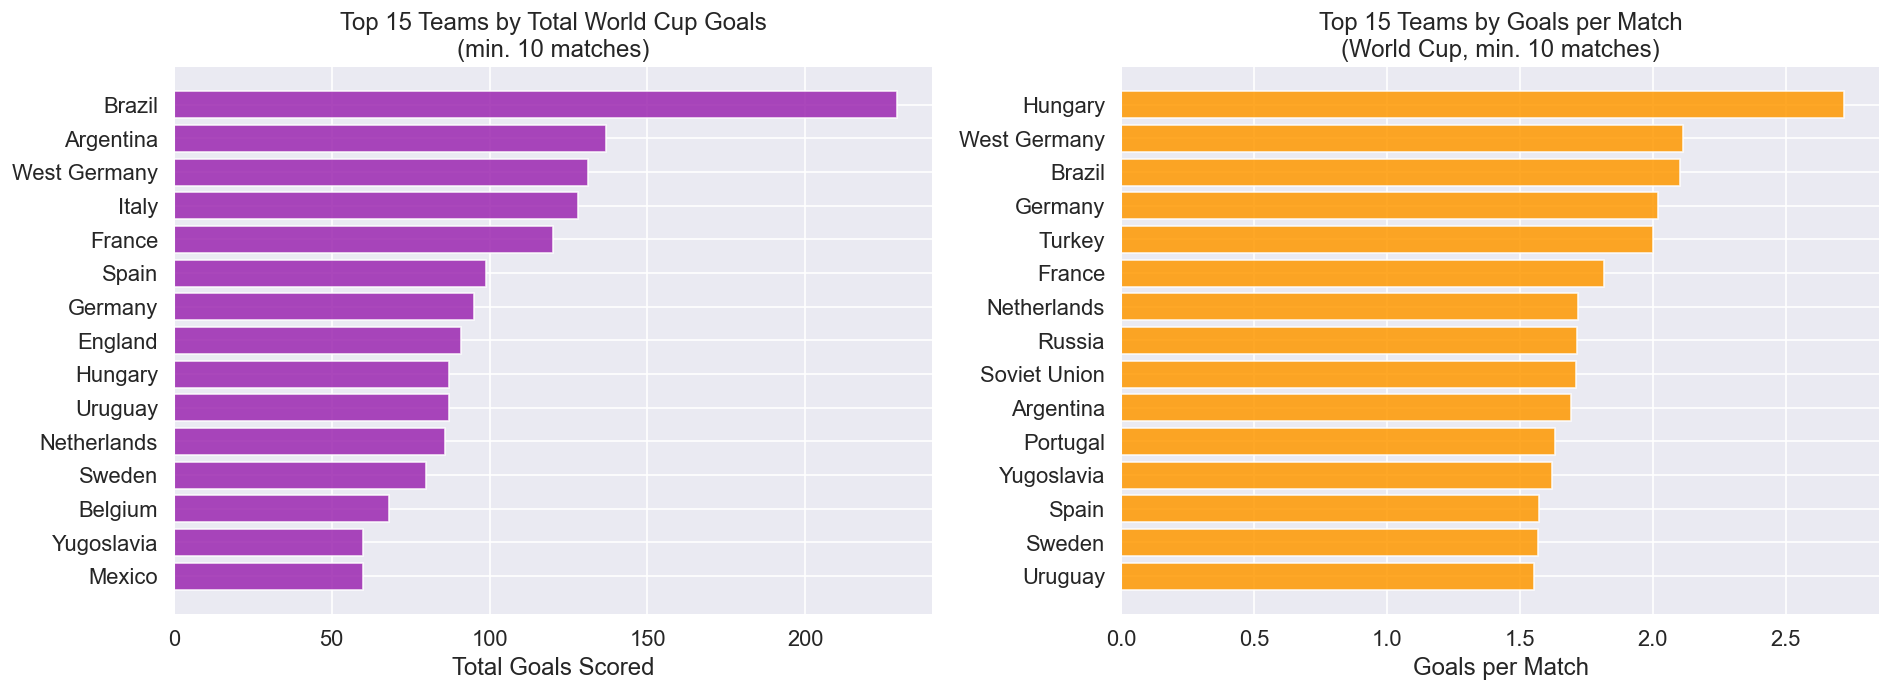

Top 10 World Cup teams by total goals:
        team  total_matches  goals  goals_per_match
      Brazil        109.000    229            2.100
   Argentina         81.000    137            1.690
West Germany         62.000    131            2.110
       Italy         83.000    128            1.540
      France         66.000    120            1.820
       Spain         63.000     99            1.570
     Germany         47.000     95            2.020
     England         69.000     91            1.320
     Hungary         32.000     87            2.720
     Uruguay         56.000     87            1.550


In [22]:
# Use joshfjelstul World Cup database
# Count appearances, wins, goals per team
df_wc_app = df_wc_matches.copy()

# Goals scored per team (combining home and away)
home_goals = df_wc_app.groupby("home_team_name")["home_team_score"].sum().reset_index()
home_goals.columns = ["team", "goals"]
away_goals = df_wc_app.groupby("away_team_name")["away_team_score"].sum().reset_index()
away_goals.columns = ["team", "goals"]
total_goals_wc = pd.concat([home_goals, away_goals]).groupby("team")["goals"].sum().reset_index()

# Appearances (matches played)
home_apps = df_wc_app["home_team_name"].value_counts().reset_index()
home_apps.columns = ["team", "home_matches"]
away_apps = df_wc_app["away_team_name"].value_counts().reset_index()
away_apps.columns = ["team", "away_matches"]
total_apps = home_apps.merge(away_apps, on="team", how="outer").fillna(0)
total_apps["total_matches"] = total_apps["home_matches"] + total_apps["away_matches"]

# Combine
wc_stats = total_apps.merge(total_goals_wc, on="team", how="left").fillna(0)
wc_stats["goals_per_match"] = wc_stats["goals"] / wc_stats["total_matches"]
wc_stats = wc_stats[wc_stats["total_matches"] >= 10].sort_values("goals", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 15 by total goals
top15 = wc_stats.head(15)
axes[0].barh(top15["team"], top15["goals"], color="#9C27B0", alpha=0.85, edgecolor="white")
axes[0].invert_yaxis()
axes[0].set_title("Top 15 Teams by Total World Cup Goals\n(min. 10 matches)")
axes[0].set_xlabel("Total Goals Scored")

# Top 15 by goals per match
top15_gpm = wc_stats.nlargest(15, "goals_per_match")
axes[1].barh(top15_gpm["team"], top15_gpm["goals_per_match"], color="#FF9800", alpha=0.85, edgecolor="white")
axes[1].invert_yaxis()
axes[1].set_title("Top 15 Teams by Goals per Match\n(World Cup, min. 10 matches)")
axes[1].set_xlabel("Goals per Match")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "10_wc_historical_dominance.png", dpi=150, bbox_inches="tight")
plt.show()

print("Top 10 World Cup teams by total goals:")
print(wc_stats[["team", "total_matches", "goals", "goals_per_match"]].head(10).round(2).to_string(index=False))

## 4. WC2026 Baseline Analysis
### 4.1 Elo baseline probabilities — group stage overview

Total group matches in baseline : 72
Matches with full Elo data      : 51
Placeholder matches (TBD teams) : 21


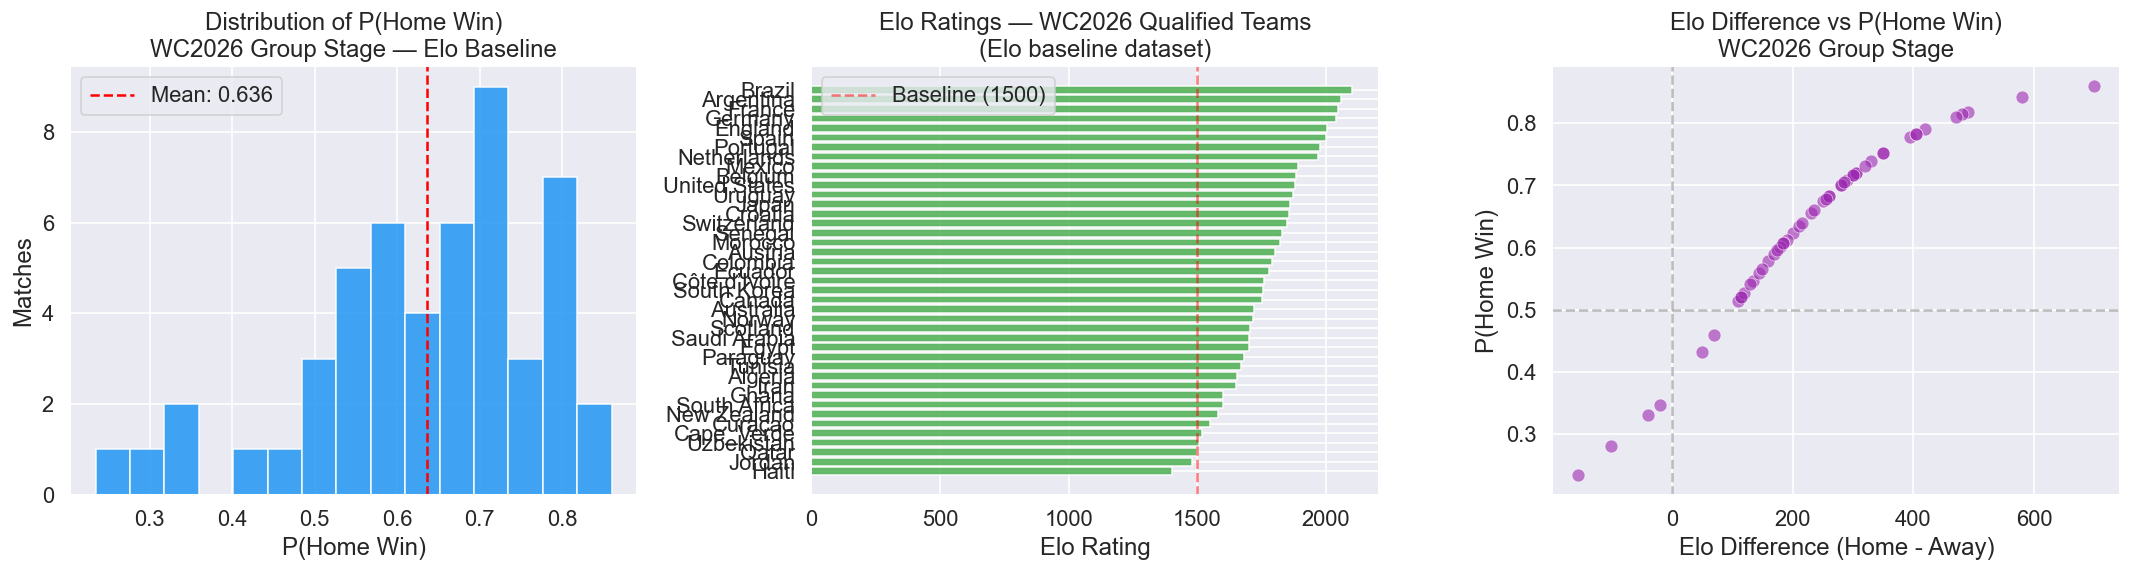


Top 10 strongest teams by Elo (WC2026 baseline):
       team      elo
     Brazil 2100.000
  Argentina 2060.000
     France 2045.000
    Germany 2040.000
    England 2005.000
      Spain 2000.000
   Portugal 1975.000
Netherlands 1970.000
     Mexico 1890.000
    Belgium 1885.000


In [23]:
# Analyze the Elo baseline dataset for WC2026
df_base = df_elo_baseline.copy()

# Remove placeholder matches (NaN away_elo)
df_base_clean = df_base.dropna(subset=["away_elo"]).copy()

print(f"Total group matches in baseline : {len(df_base)}")
print(f"Matches with full Elo data      : {len(df_base_clean)}")
print(f"Placeholder matches (TBD teams) : {len(df_base) - len(df_base_clean)}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Distribution of p_home_win ---
axes[0].hist(df_base_clean["p_home_win"], bins=15, color="#2196F3", edgecolor="white", alpha=0.85)
axes[0].set_title("Distribution of P(Home Win)\nWC2026 Group Stage — Elo Baseline")
axes[0].set_xlabel("P(Home Win)")
axes[0].set_ylabel("Matches")
axes[0].axvline(df_base_clean["p_home_win"].mean(), color="red", linestyle="--",
    label=f"Mean: {df_base_clean['p_home_win'].mean():.3f}")
axes[0].legend()

# --- Elo ratings of WC2026 teams ---
all_elos = pd.concat([
    df_base_clean[["home_team", "home_elo"]].rename(columns={"home_team": "team", "home_elo": "elo"}),
    df_base_clean[["away_team", "away_elo"]].rename(columns={"away_team": "team", "away_elo": "elo"}),
]).drop_duplicates(subset=["team"]).sort_values("elo", ascending=True)

axes[1].barh(all_elos["team"], all_elos["elo"], color="#4CAF50", alpha=0.85, edgecolor="white")
axes[1].set_title("Elo Ratings — WC2026 Qualified Teams\n(Elo baseline dataset)")
axes[1].set_xlabel("Elo Rating")
axes[1].axvline(1500, color="red", linestyle="--", alpha=0.5, label="Baseline (1500)")
axes[1].legend()

# --- p_home_win vs elo_diff scatter ---
axes[2].scatter(df_base_clean["elo_diff"], df_base_clean["p_home_win"],
    alpha=0.6, color="#9C27B0", edgecolors="white", linewidths=0.5, s=60)
axes[2].set_title("Elo Difference vs P(Home Win)\nWC2026 Group Stage")
axes[2].set_xlabel("Elo Difference (Home - Away)")
axes[2].set_ylabel("P(Home Win)")
axes[2].axhline(0.5, color="gray", linestyle="--", alpha=0.5)
axes[2].axvline(0, color="gray", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "11_elo_baseline_wc2026.png", dpi=150, bbox_inches="tight")
plt.show()

# Top 5 most likely winners by average p_home_win as home team
print("\nTop 10 strongest teams by Elo (WC2026 baseline):")
print(all_elos.sort_values("elo", ascending=False).head(10).to_string(index=False))

## 5. Key Findings Summary
### EDA conclusions for feature engineering and modeling

In [24]:
print("=" * 65)
print("EDA KEY FINDINGS — FIFA World Cup 2026 Predictor")
print("=" * 65)

print("""
1. GOALS DISTRIBUTION
   - Mean goals/match: 2.94 (all internationals) vs 2.82 (WC only)
   - WC matches are lower-scoring and more competitive
   - Goals peaked in 1950s (~4.0/match) and declined to ~2.7 modern era

2. HOME ADVANTAGE
   - All internationals: 49% HW / 23% D / 28% AW
   - World Cup (neutral): 45.5% HW / 22% D / 32.3% AW
   - Neutral venue reduces home advantage by ~3.5pp → model must use is_neutral flag

3. ELO PREDICTIVE POWER (strongest feature)
   - Elo diff > +300: 91.6% home win rate
   - Elo diff < -300: 73.4% away win rate
   - Correlation with goal_diff: 0.515

4. FIFA RANKING PREDICTIVE POWER
   - Rank diff > 100 (home worse): 87.9% away win rate
   - Confirms ranking as strong secondary feature
   - Correlation slightly weaker than Elo

5. FORM FEATURES
   - Home win rate signal: ~0.10 difference between winners and losers
   - Weaker than Elo but additive signal → include in model

6. TEMPORAL TRENDS
   - Away win rate increasing over time (28% → 33% 2021-2026)
   - Goles per match stable at ~2.7 in modern era
   - Model should weight recent matches more heavily

7. WC2026 SPECIFIC
   - 42/42 confirmed teams matched across all datasets
   - 6 placeholder teams (UEFA/FIFA playoffs) → assign mean Elo
   - West Germany unified with Germany in historical stats

8. DATASETS QUALITY
   - df_match_features: 35 pre-calculated features, minimal nulls
   - df_results: 49,071 matches, zero nulls, zero duplicates
   - df_rankings: covers all 42 confirmed WC2026 teams
""")

print("=" * 65)
print(f"Figures saved to: {FIGURES_DIR}")
print(f"Total figures generated: {len(list(FIGURES_DIR.glob('*.png')))}")

EDA KEY FINDINGS — FIFA World Cup 2026 Predictor

1. GOALS DISTRIBUTION
   - Mean goals/match: 2.94 (all internationals) vs 2.82 (WC only)
   - WC matches are lower-scoring and more competitive
   - Goals peaked in 1950s (~4.0/match) and declined to ~2.7 modern era

2. HOME ADVANTAGE
   - All internationals: 49% HW / 23% D / 28% AW
   - World Cup (neutral): 45.5% HW / 22% D / 32.3% AW
   - Neutral venue reduces home advantage by ~3.5pp → model must use is_neutral flag

3. ELO PREDICTIVE POWER (strongest feature)
   - Elo diff > +300: 91.6% home win rate
   - Elo diff < -300: 73.4% away win rate
   - Correlation with goal_diff: 0.515

4. FIFA RANKING PREDICTIVE POWER
   - Rank diff > 100 (home worse): 87.9% away win rate
   - Confirms ranking as strong secondary feature
   - Correlation slightly weaker than Elo

5. FORM FEATURES
   - Home win rate signal: ~0.10 difference between winners and losers
   - Weaker than Elo but additive signal → include in model

6. TEMPORAL TRENDS
   - Away

## 6. Design Decisions for Feature Engineering & Modeling

### 6.1 Temporal weighting strategy

In [26]:
print("""
FEATURE ENGINEERING DESIGN DECISIONS
======================================

1. TEMPORAL SIGNAL OVER HISTORICAL REPUTATION
   - Recent form (last 5/10/20 matches) weighted exponentially
   - Elo recalculated from scratch on df_results with dynamic K-factor
   - Features computed AS OF match date — never use future information
   - Training set: exponential sample weights (recent matches penalized less)
   - Rationale: Argentina 2022 ≠ Argentina 2026. Brazil's historical
     dominance does not predict 2026 performance.

2. FEATURE CATEGORIES AND EXPECTED SIGNAL STRENGTH
   ┌─────────────────────────────┬──────────┬─────────────────────────┐
   │ Feature                     │ Signal   │ Source                  │
   ├─────────────────────────────┼──────────┼─────────────────────────┤
   │ Elo difference              │ STRONG   │ Calculated from results │
   │ FIFA ranking difference     │ STRONG   │ cashncarry dataset      │
   │ Form win rate (last 10)     │ MEDIUM   │ lchikry / calculated    │
   │ Form goals scored (last 10) │ MEDIUM   │ lchikry / calculated    │
   │ Form goals conceded (last10)│ MEDIUM   │ lchikry / calculated    │
   │ Is neutral venue            │ MEDIUM   │ df_results              │
   │ Is World Cup                │ LOW-MED  │ tournament flag         │
   │ Coach tenure (months)       │ LOW-MED  │ external (future)       │
   │ Squad market value diff     │ LOW      │ Transfermarkt (future)  │
   │ World Cup wins (historical) │ CONTEXT  │ NOT a predictor         │
   │ Total goals (historical)    │ CONTEXT  │ NOT a predictor         │
   └─────────────────────────────┴──────────┴─────────────────────────┘

3. MODEL WEIGHTS (sample_weight in sklearn/XGBoost)
   - Exponential decay: w(t) = exp(lambda * days_before_cutoff)
   - Lambda to tune via cross-validation
   - WC matches get additional weight multiplier (higher stakes)
   - Friendlies get weight penalty (lower stakes, rotated squads)

4. UNSUPERVISED METHODS — INTEGRATION PLAN
   A) CLUSTERING (before feature engineering):
      - K-Means + DBSCAN on 48 WC2026 teams
      - Features: current Elo, FIFA rank, form metrics
      - Output: cluster label as categorical feature for supervised model
      - Also: detect outliers (teams punching above/below their weight)

   B) PCA (before modeling):
      - Apply on full feature matrix
      - Detect multicollinearity (elo_diff vs overall_diff are correlated)
      - Use explained variance to decide feature reduction strategy
      - PCA components as optional additional features

   C) ANOMALY DETECTION:
      - Identify teams whose recent form diverges from historical profile
      - Example: a low-ranked team on a 10-game winning streak
      - Flag as high-uncertainty predictions in Monte Carlo

5. TEMPORAL SPLIT STRATEGY
   - Train  : all matches up to Dec 2021
   - Val    : Jan 2022 — Dec 2023
   - Test   : Jan 2024 — present
   - WC2026 : prediction target (no labels)
   - NEVER random split on time-series data
""")


FEATURE ENGINEERING DESIGN DECISIONS

1. TEMPORAL SIGNAL OVER HISTORICAL REPUTATION
   - Recent form (last 5/10/20 matches) weighted exponentially
   - Elo recalculated from scratch on df_results with dynamic K-factor
   - Features computed AS OF match date — never use future information
   - Training set: exponential sample weights (recent matches penalized less)
   - Rationale: Argentina 2022 ≠ Argentina 2026. Brazil's historical
     dominance does not predict 2026 performance.

2. FEATURE CATEGORIES AND EXPECTED SIGNAL STRENGTH
   ┌─────────────────────────────┬──────────┬─────────────────────────┐
   │ Feature                     │ Signal   │ Source                  │
   ├─────────────────────────────┼──────────┼─────────────────────────┤
   │ Elo difference              │ STRONG   │ Calculated from results │
   │ FIFA ranking difference     │ STRONG   │ cashncarry dataset      │
   │ Form win rate (last 10)     │ MEDIUM   │ lchikry / calculated    │
   │ Form goals scored (last 